In [ ]:
#تحميل الداتا
import pandas as pd

df = pd.read_csv("resume_clean_dataset.csv")

df.head()

,file_path,category,raw_text,text_length,clean_text,clean_text_length
0,C:\Users\hp\Downloads\archive (3)\data\data\AC...,ACCOUNTANT,ACCOUNTANT Summary Financial Accountant specia...,24153,accountant summary financial accountant specia...,23450
1,C:\Users\hp\Downloads\archive (3)\data\data\AC...,ACCOUNTANT,STAFF ACCOUNTANT Summary Highly analytical and...,7488,staff accountant summary highly analytical and...,7166
2,C:\Users\hp\Downloads\archive (3)\data\data\AC...,ACCOUNTANT,ACCOUNTANT Professional Summary To obtain a po...,4742,accountant professional summary to obtain a po...,4512
3,C:\Users\hp\Downloads\archive (3)\data\data\AC...,ACCOUNTANT,SENIOR ACCOUNTANT Experience Company Name June...,5917,senior accountant experience company name june...,5621
4,C:\Users\hp\Downloads\archive (3)\data\data\AC...,ACCOUNTANT,SENIOR ACCOUNTANT Professional Summary Senior ...,5561,senior accountant professional summary senior ...,5353


In [3]:
#تحديد X و y
X = df["clean_text"].fillna("")
y = df["category"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of categories:", y.nunique())

X shape: (2481,)
y shape: (2481,)
Number of categories: 24


In [4]:
#تقسيم الداتا Train / Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1984
Testing samples: 497


In [5]:
#تدريب أول موديل
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [6]:
#تقييم الموديل
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.6680080482897385

                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.83      0.74        24
              ADVOCATE       0.75      0.50      0.60        24
           AGRICULTURE       0.44      0.62      0.52        13
               APPAREL       0.71      0.63      0.67        19
                  ARTS       0.62      0.38      0.47        21
            AUTOMOBILE       0.33      0.14      0.20         7
              AVIATION       0.86      0.78      0.82        23
               BANKING       0.57      0.52      0.55        23
                   BPO       0.33      0.25      0.29         4
  BUSINESS-DEVELOPMENT       0.44      0.71      0.54        24
                  CHEF       0.89      0.71      0.79        24
          CONSTRUCTION       0.83      0.68      0.75        22
            CONSULTANT       0.40      0.17      0.24        23
              DESIGNER       0.88      0.71      0.79        21
         

In [7]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Linear SVC": LinearSVC(class_weight="balanced", max_iter=5000),
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB()
}

results = []
trained_models = {}

for name, classifier in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=20000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.90,
            sublinear_tf=True
        )),
        ("classifier", classifier)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })
    
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,Macro F1,Weighted F1
1,Linear SVC,0.712274,0.683513,0.703662
0,Logistic Regression,0.651911,0.605303,0.636169
3,Complement NB,0.571429,0.505006,0.532504
2,Multinomial NB,0.527163,0.442285,0.482759


In [ ]:
#أفضل موديل
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", results_df.iloc[0]["Accuracy"])
print("Best Macro F1:", results_df.iloc[0]["Macro F1"])
print("Best Weighted F1:", results_df.iloc[0]["Weighted F1"])

Best Model: Linear SVC
Best Accuracy: 0.7122736418511066
Best Macro F1: 0.6835126611645385
Best Weighted F1: 0.7036615608254234


In [20]:
#تقرير الكامل
from sklearn.metrics import classification_report

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.69      0.92      0.79        24
              ADVOCATE       0.71      0.71      0.71        24
           AGRICULTURE       0.75      0.69      0.72        13
               APPAREL       0.69      0.58      0.63        19
                  ARTS       0.75      0.29      0.41        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.91      0.91      0.91        23
               BANKING       0.67      0.70      0.68        23
                   BPO       1.00      0.25      0.40         4
  BUSINESS-DEVELOPMENT       0.55      0.75      0.63        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.80      0.73      0.76        22
            CONSULTANT       0.62      0.43      0.51        23
              DESIGNER       0.89      0.81      0.85        21
         DIGITAL-MEDIA       0.64      

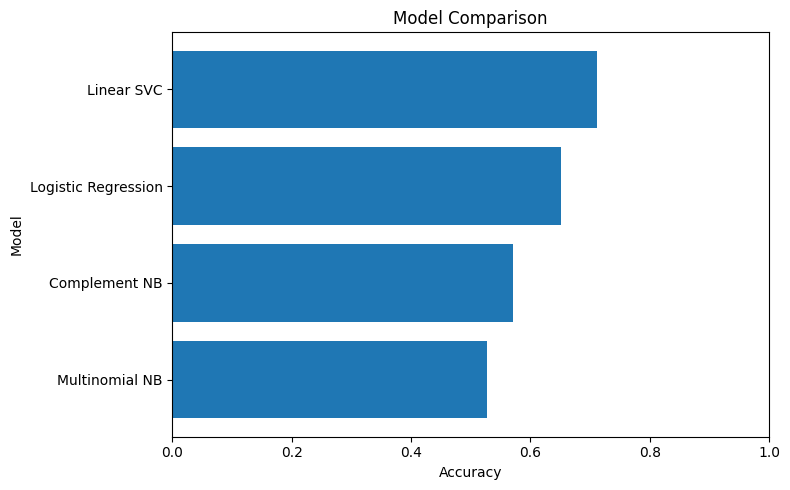

In [ ]:
#رسم مقارنة النماذج
import matplotlib.pyplot as plt

results_df = results_df.sort_values("Accuracy")

plt.figure(figsize=(8,5))
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

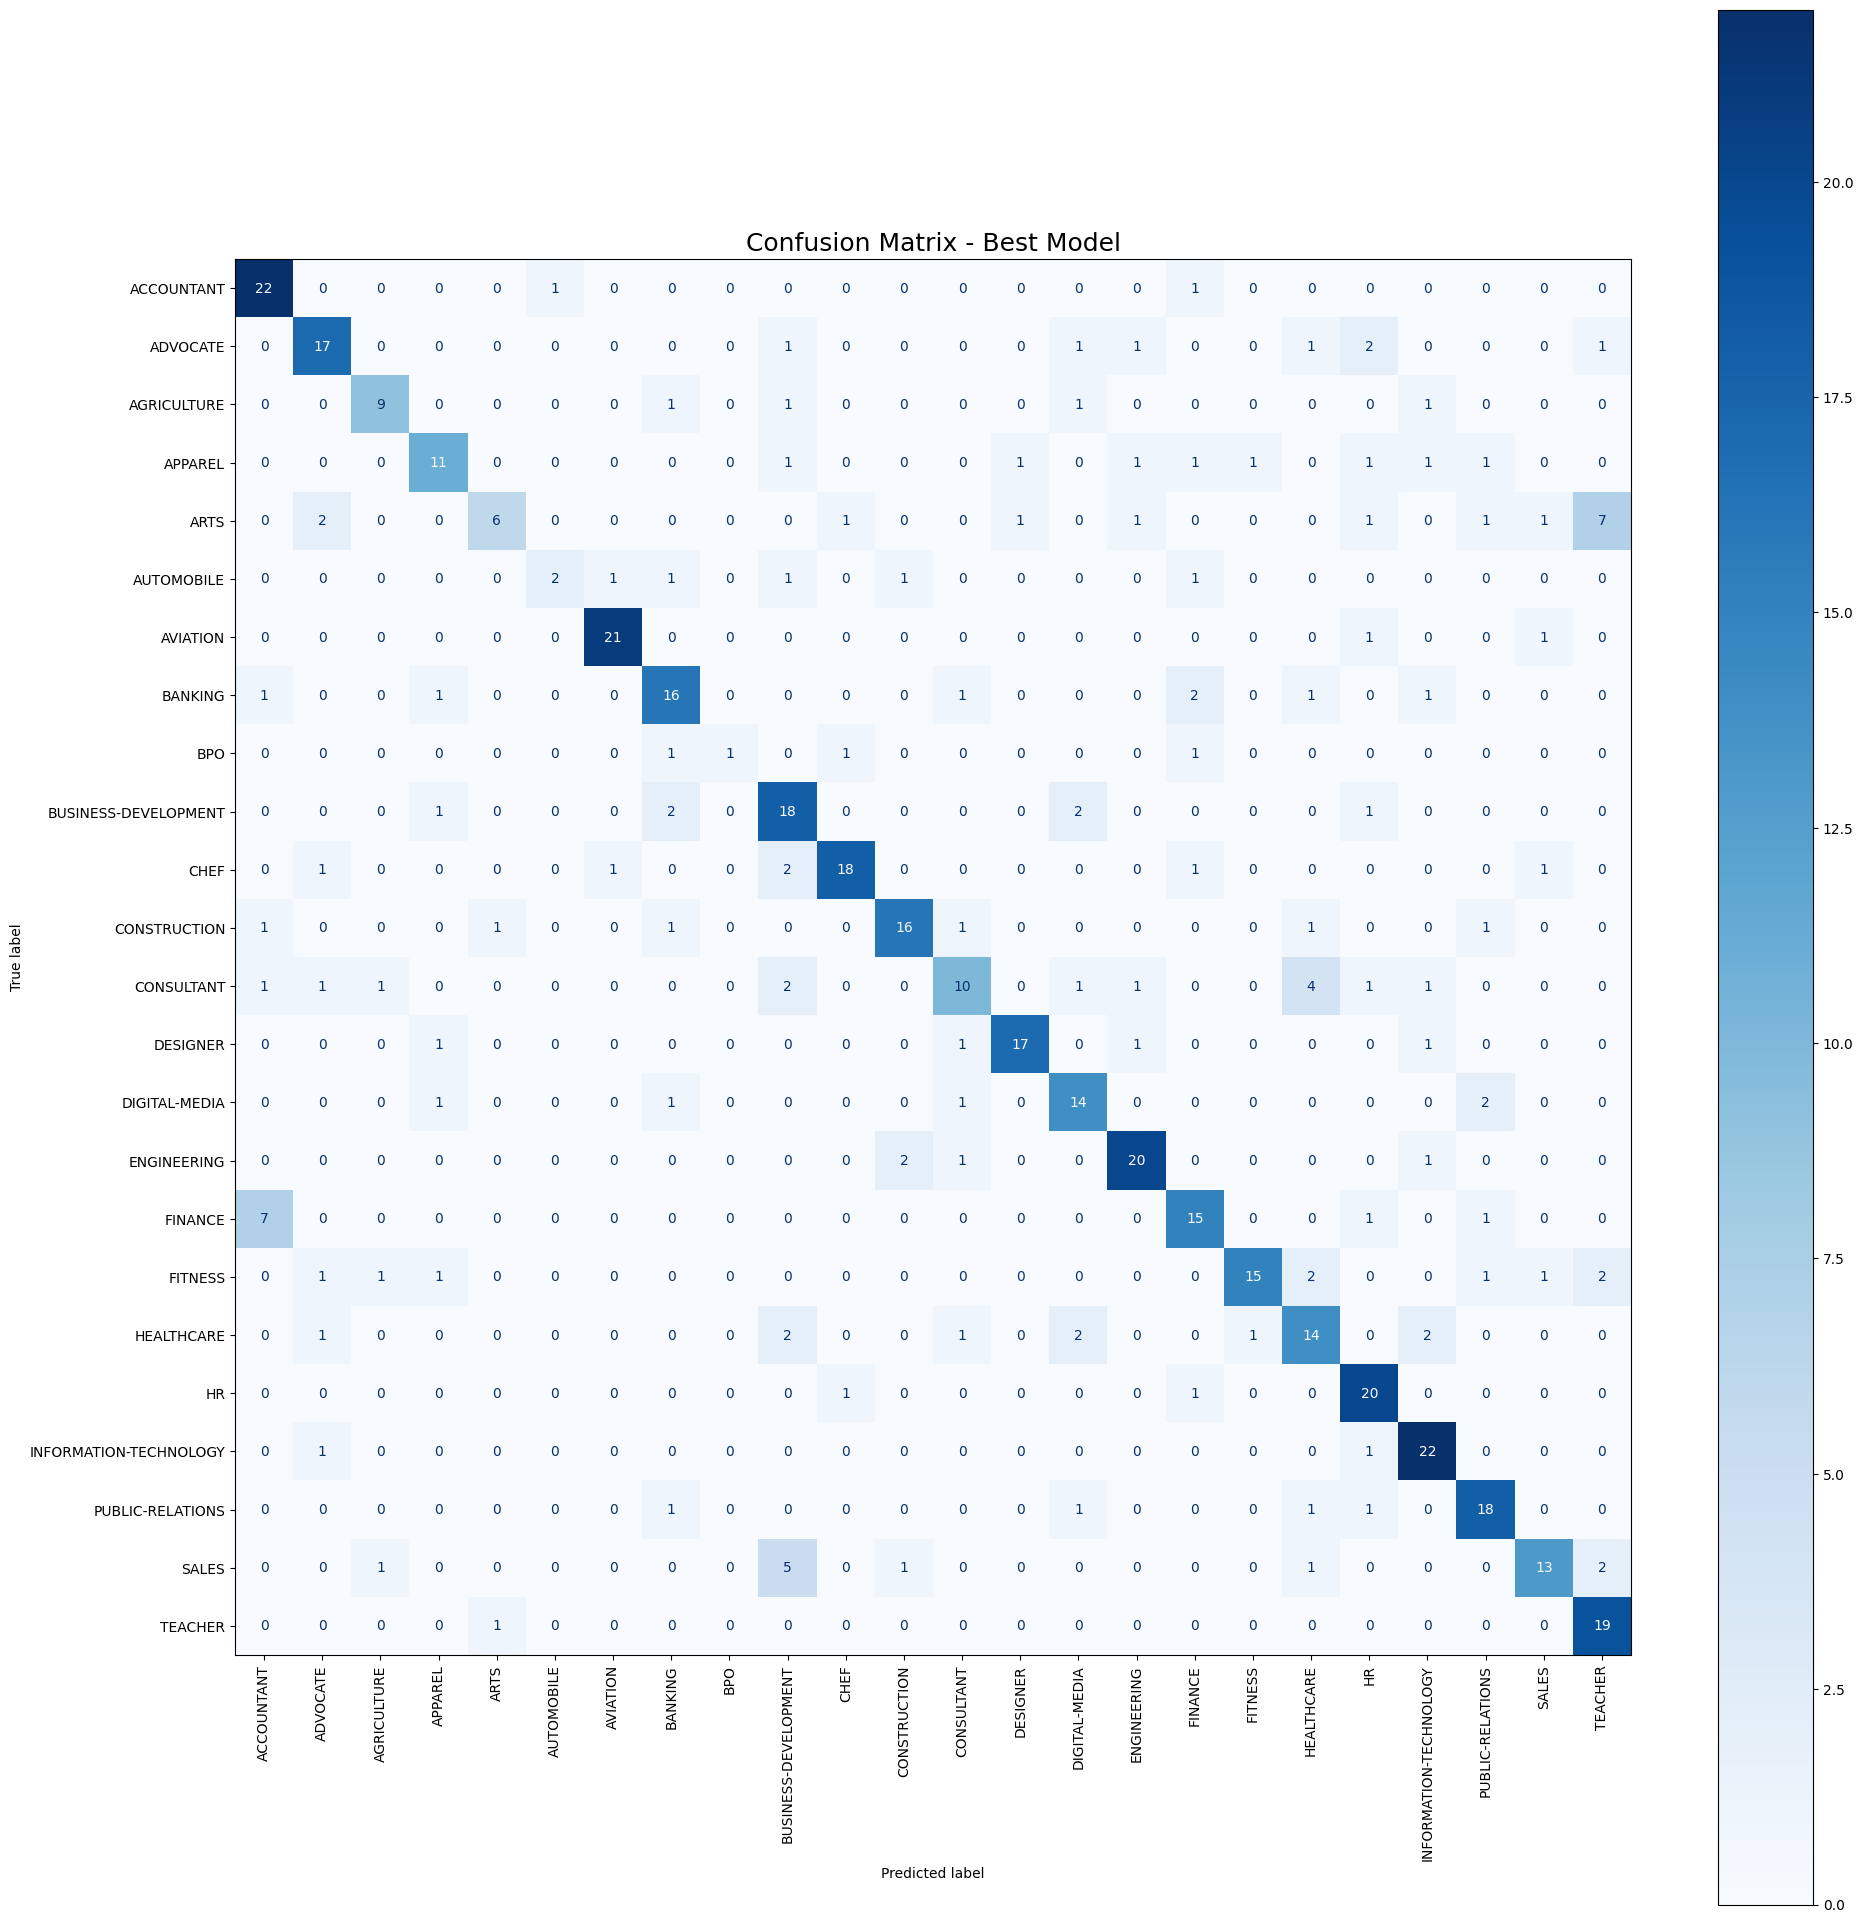

In [19]:
#Confusion Matrix  لأفضل موديل
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - Best Model", fontsize=18)
plt.tight_layout()
plt.show()

In [15]:
#③ Cross Validation   بدل الاعتماد على تقسيمة واحدة فقط.

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.6861167  0.71169355 0.72379032 0.70564516 0.70564516]
0.7065781787499188


In [16]:
#تجربة النموذج على CV جديد
resume = """
Python
Machine Learning
SQL
Power BI
Tableau
Pandas
Deep Learning
"""

prediction = best_model.predict([resume])

print(prediction)

['ENGINEERING']


In [10]:
#حفظ الموديل
import joblib

joblib.dump(best_model, "best_resume_classifier_model.pkl")

['best_resume_classifier_model.pkl']

In [11]:
#عشان اتاكد انو انحفظ
import os

print(os.path.exists("best_resume_classifier_model.pkl"))

True


In [21]:
sorted(df["category"].unique())

['ACCOUNTANT',
 'ADVOCATE',
 'AGRICULTURE',
 'APPAREL',
 'ARTS',
 'AUTOMOBILE',
 'AVIATION',
 'BANKING',
 'BPO',
 'BUSINESS-DEVELOPMENT',
 'CHEF',
 'CONSTRUCTION',
 'CONSULTANT',
 'DESIGNER',
 'DIGITAL-MEDIA',
 'ENGINEERING',
 'FINANCE',
 'FITNESS',
 'HEALTHCARE',
 'HR',
 'INFORMATION-TECHNOLOGY',
 'PUBLIC-RELATIONS',
 'SALES',
 'TEACHER']